# [LAB-10] 4-3. 분류 성능 평가 모듈화 - 연습문제

## 준비작업

### 라이브러리 참조

In [1]:
# 라이브러리 기본 참조
from hossam import load_data
from helpers import *
from pandas import DataFrame

import numpy as np

# 분류 성능 평가를 위한 참조
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

📦 아이티윌 이광호 강사가 제작한 라이브러리를 사용중입니다.
📚 자세한 사용 방법은 https://py.hossam.kr 을 참고하세요.
📧 Email: leekh4232@gmail.com
🎬 Youtube: https://www.youtube.com/@hossam-codingclub
📝 Blog: https://blog.hossam.kr/
🔖 Version: develop


## 📚 입학사정관실 신입 분석가의 검증 의뢰

### 당신은 한울대학교 간호대학원 입학사정관실에 배치된 신입 분석가입니다.

지난 입시에 지원한 377명의 성별·필기점수·학부성적·병원경력과 최종 합격 여부가 정리되어 남아 있고, 사정관실은 이 기록으로 "합격 가능성 예측 모형"을 만들어 예비 지원자 상담에 쓰려고 합니다.

실장님은 "정확도가 70% 가까이 나온다니 이번 상담부터 바로 쓰자"고 합니다. 그런데 합격자는 지원자의 3분의 1뿐이라는 점이 마음에 걸립니다.

이 모형을 상담 현장에 내보내도 되는지, 성능 지표를 하나씩 확인해서 판단하세요.

### 💻 코드 작성

#### 데이터 가져오기

In [2]:
origin = load_data('nursing_grades_preprocessed')
origin.head()

📚 어느 간호학과 대학원에 지원한 학생들에 대한 합격/불합격 여부를 조사한 가상의 데이터에 대한 전처리 완료 버전


,성별,필기점수,학부성적,병원경력,합격여부
0,0,380,3.610,3,0
1,0,660,3.670,3,1
2,0,800,4.000,1,1
3,1,640,3.190,4,1
4,0,520,2.930,4,0


#### 정답의 구성 비율과 '게으른 모형'의 정확도

In [3]:
y_real = origin['합격여부']

# 종속변수의 값별 개수와 비율
count = y_real.value_counts()
ratio = y_real.value_counts(normalize=True)
display(DataFrame({"인원수": count, "비율": ratio}))

# 아무 것도 계산하지 않고 무조건 '불합격(0)'이라고만 답하는 모형
y_lazy = np.zeros(len(y_real), dtype=int)
print(f"'무조건 불합격' 모형의 정확도 : {accuracy_score(y_real, y_lazy):.3f}")

,인원수,비율
합격여부,,
0,250,0.663
1,127,0.337


'무조건 불합격' 모형의 정확도 : 0.663


#### 분류모델 적합

In [4]:
fit = my_logit.auto_logit(origin, '합격여부', plot=False, report=False)

#### 분류 성능 평가

,예측 0 (Negative),예측 1 (Positive)
실제 0 (Negative),226,24
실제 1 (Positive),92,35


,정확도(Accuracy),정밀도(Precision),"재현율(Recall,TPR)","위양성율(Fallout,FPR)","특이성(Specificity,TNR)",F1,AUC,AUC 판단,진단오즈비(DOR)
performance,0.692,0.593,0.276,0.096,0.904,0.376,0.690,낮음,3.582


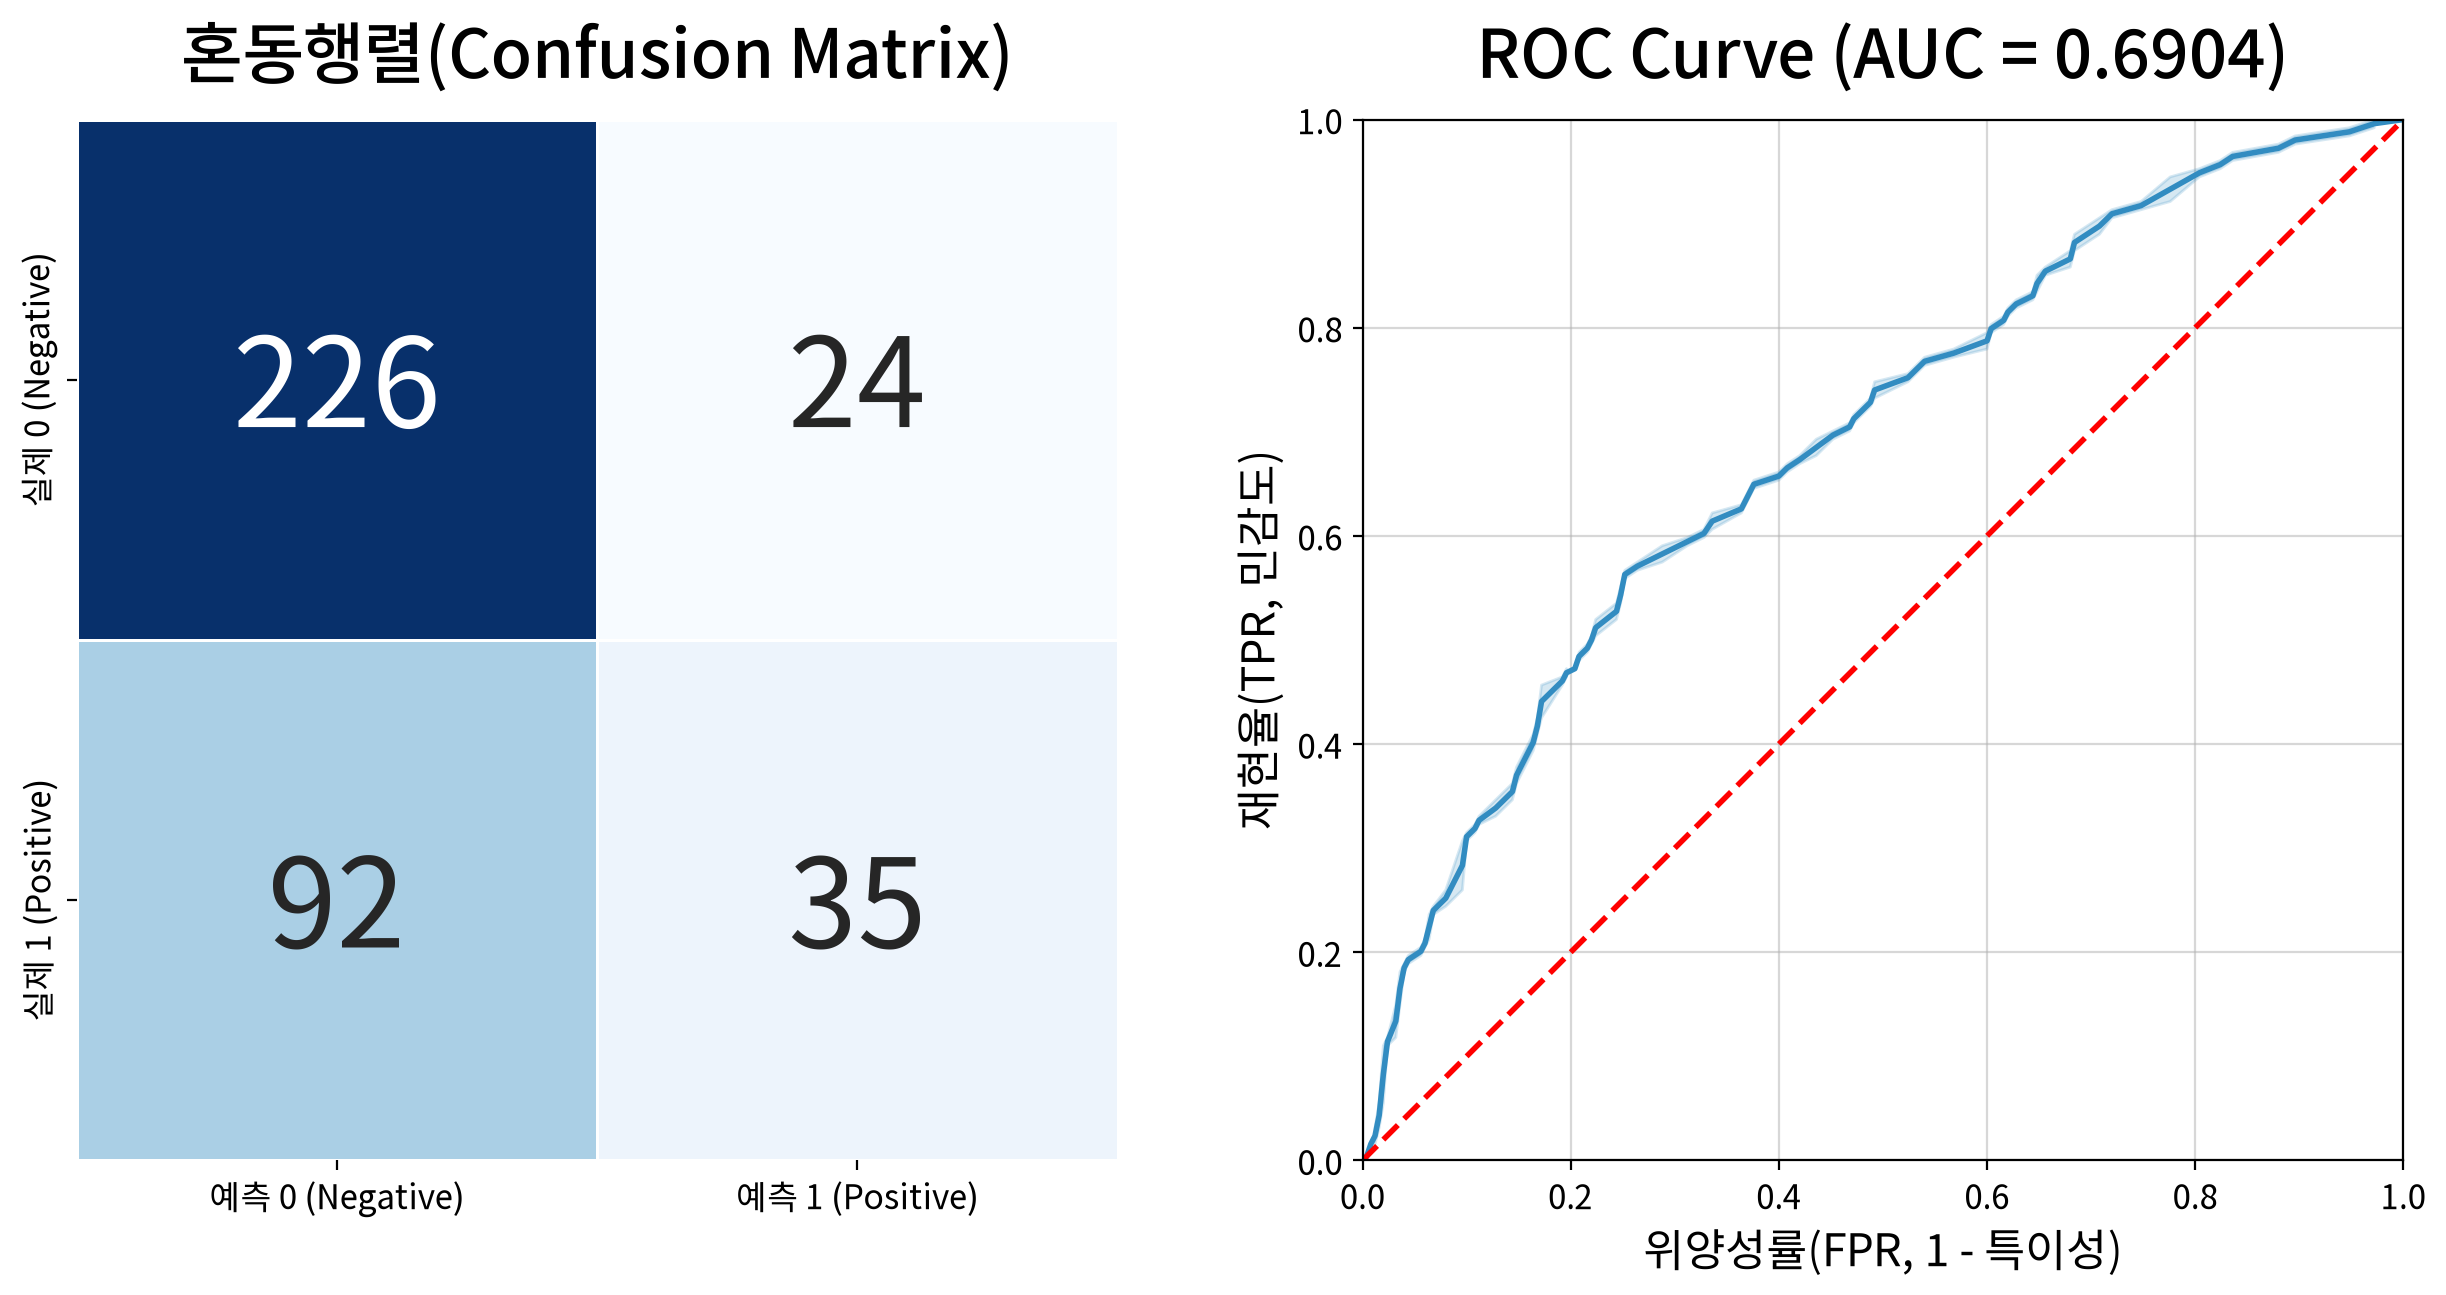

In [5]:
my_logit.report_performance(fit)

#### 임계값을 바꿔가며 지표 관찰

In [6]:
y_true = np.asarray(fit.model.endog).astype(int)   # 실제 합격 여부(0/1)
proba = np.asarray(fit.predict())                 # 합격(1)일 예측 확률

rows = []

for t in [0.3, 0.4, 0.5, 0.6, 0.7]:   # 임계값을 0.3 ~ 0.7로 바꿔가며 관찰
    p = (proba > t).astype(int)       # 임계값 t로 이진화
    rows.append({
        "임계값": t,
        "정확도": accuracy_score(y_true, p),
        "정밀도": precision_score(y_true, p, zero_division=0),
        "재현율": recall_score(y_true, p, zero_division=0),
        "F1": f1_score(y_true, p, zero_division=0),
        "놓친 합격자수(FN)": confusion_matrix(y_true, p).ravel()[2],
    })

display(DataFrame(rows).round(3))

,임계값,정확도,정밀도,재현율,F1,놓친 합격자수(FN)
0,0.300,0.586,0.433,0.732,0.544,34
1,0.400,0.690,0.541,0.520,0.530,61
2,0.500,0.692,0.593,0.276,0.376,92
3,0.600,0.682,0.652,0.118,0.200,112
4,0.700,0.660,0.400,0.016,0.030,125


### 문제 풀이

#### 1. 실장님이 말한 "정확도 70%"가 정말 잘한 성적인지 비교할 기준이 필요합니다. 아무 계산도 하지 않고 지원자 전원을 무조건 불합격이라고만 찍는 모형의 정확도는 얼마인가요? (소수 셋째 자리)

- **정답**: `0.663`
- **복습 개념**: 불균형 데이터에서의 정확도의 함정입니다. 정확도는 절대적인 점수가 아니라, "다수 범주로만 찍는 게으른 모형"이라는 기준선과 비교해야 의미가 생깁니다. 이 기준선을 기저율(base rate)이라고 부릅니다.
- **풀이 접근**: 종속변수의 값별 개수와 비율을 세어 어느 쪽이 다수인지 확인합니다. 그다음 실제 정답과 길이가 같고 전부 0(불합격)으로 채워진 예측 배열을 만들어 정확도를 구합니다. 계산하지 않고 다수 범주의 비율을 그대로 읽어도 같은 값입니다.
- **근거(계산 결과)**: 불합격(0) **250명(66.3%)**, 합격(1) 127명(33.7%)입니다. 전원을 0으로 찍으면 250명을 맞히므로 250 / 377 = **0.663**입니다. 위 코드의 출력에서 `'무조건 불합격' 모형의 정확도 : 0.663` 으로 확인됩니다.
- **함께 생각해 볼 점**: 잠시 뒤 나올 실제 모형의 정확도는 0.692입니다. 필기점수·학부성적·병원경력을 모두 동원해 얻은 이득이 게으른 모형보다 겨우 **2.9%p**라는 뜻입니다. 정확도라는 숫자 하나만 보고 "70%면 쓸 만하다"고 말하기 어려운 이유가 여기에 있습니다.

#### 2. 상담에서 가장 아픈 실수는 합격할 수 있었던 지원자에게 "어렵겠다"고 말하는 경우입니다. 임계값 0.5에서 실제로는 합격했는데 모형이 불합격으로 예측한 지원자는 몇 명인가요?

- **정답**: `92`
- **복습 개념**: 혼동행렬의 FN(False Negative, 놓침) 칸입니다. 같은 오답이라도 FP(헛짚음)와 FN은 현장에서의 대가가 전혀 다르므로, 틀린 개수를 뭉뚱그리지 말고 두 종류로 나눠 봐야 합니다.
- **풀이 접근**: 적합된 모형에서 실제값과 예측 확률을 꺼내고, 임계값 0.5로 확률을 0/1로 자른 뒤 실제값과 대조한 2×2 표를 만듭니다. 그 표에서 '실제 1(Positive) × 예측 0(Negative)' 칸을 읽습니다.
- **근거(계산 결과)**: 혼동행렬은 TN 226 / FP 24 / **FN 92** / TP 35 입니다. 합격자 127명 중 모형이 찾아낸 사람은 35명뿐이고, 나머지 **92명**은 불합격으로 분류되었습니다.
- **자주 하는 실수**: 혼동행렬의 네 칸 위치를 헷갈려 FP(24)를 답하기 쉽습니다. 행은 실제, 열은 예측이라는 순서를 먼저 확인하세요. 배열로 풀 때도 `tn, fp, fn, tp` 순서가 정해져 있다는 점을 기억해 두면 좋습니다.

#### 3. "실제 합격자 가운데 모형이 실제로 찾아낸 비율"은 얼마인가요? (소수 셋째 자리)

- **정답**: `0.276`
- **복습 개념**: 재현율(Recall, 민감도, TPR)입니다. 분모가 **실제 양성 전체**(TP + FN)이므로, 놓침(FN)이 많을수록 낮아집니다. 정확도가 보지 못하는 "놓친 사람"의 문제를 정면으로 드러내는 지표입니다.
- **풀이 접근**: 성능 평가 결과표에서 재현율 열을 읽거나, 혼동행렬의 TP를 (TP + FN)으로 직접 나눕니다.
- **근거(계산 결과)**: 35 / (35 + 92) = 35 / 127 = **0.276** 입니다. 반면 특이성(TNR)은 0.904로 매우 높습니다. 불합격자는 잘 걸러내는데 합격자는 열 명 중 세 명도 못 찾는, 다수 범주 쪽으로 완전히 기울어진 모형입니다.
- **실무 포인트**: 정확도 0.692와 재현율 0.276이 같은 모형에서 나온 숫자입니다. 상담이라는 목적에서 중요한 쪽은 재현율입니다. 어느 지표를 보고할지는 모형이 아니라 **모형을 쓰는 목적**이 정합니다.

#### 4. 특정 임계값 하나가 아니라 모든 임계값을 통틀어 모형의 실력을 요약하는 지표가 있습니다. 성능 평가 결과표는 이 지표에 어떤 판단 등급을 붙였나요?

- **정답**: `낮음`
- **복습 개념**: AUC(ROC 곡선 아래 면적)와 그 구간별 판정입니다. AUC는 "합격자 한 명과 불합격자 한 명을 무작위로 뽑았을 때 모형이 합격자에게 더 높은 확률을 줄 가능성"으로 읽습니다. 통상 0.6 미만은 학습 실패, 0.7 미만 낮음, 0.8 미만 쓸 만함, 0.9 미만 우수, 그 이상은 매우 우수로 봅니다.
- **풀이 접근**: 성능 평가 결과표의 AUC 값과 그 옆의 판단 열을 함께 확인합니다.
- **근거(계산 결과)**: AUC = **0.690** 으로 0.7에 못 미치므로 판정은 `낮음` 입니다. 수업에서 본 당뇨 데이터의 AUC 0.843(우수)과 비교하면 확실히 처집니다.
- **헷갈리기 쉬운 점**: AUC가 낮다는 것과 임계값이 나쁘다는 것은 다른 이야기입니다. AUC는 임계값과 무관하게 매겨지는 점수이므로, **임계값을 아무리 잘 골라도 AUC 자체는 올라가지 않습니다.** 여기서는 임계값 조정만으로 해결되지 않는, 모형 자체의 한계가 드러난 셈입니다.

#### 5. 모형의 판정과 실제 결과가 얼마나 강하게 연결되어 있는지를 혼동행렬 네 칸으로 요약한 값은 얼마인가요? (소수 셋째 자리)

- **정답**: `3.582`
- **복습 개념**: 진단 오즈비(DOR)입니다. (TP × TN) / (FP × FN)로 구하며, "합격으로 판정된 사람의 실제 합격 오즈가 불합격으로 판정된 사람에 비해 몇 배인가"를 뜻합니다. 1이면 판정과 실제가 무관하다는 의미입니다.
- **풀이 접근**: 성능 평가 결과표의 진단오즈비 열을 읽거나, 혼동행렬 네 칸을 (TP × TN) / (FP × FN)에 대입합니다.
- **근거(계산 결과)**: (35 × 226) / (24 × 92) = 7910 / 2208 = **3.582** 입니다. 1보다는 크므로 판정이 무의미하지는 않지만, 당뇨 데이터에서 본 10.13에 비하면 연결의 강도가 훨씬 약합니다.

#### 6. 상담에 쓰려면 놓치는 합격자를 줄여야 합니다. 임계값을 0.3부터 0.7까지 0.1씩 바꿔 볼 때, 정밀도와 재현율을 함께 반영한 점수가 가장 높아지는 임계값은 얼마인가요?

- **정답**: `0.3`
- **복습 개념**: 정밀도-재현율 트레이드오프와 F1 점수입니다. 임계값을 낮추면 양성으로 판정하는 범위가 넓어져 재현율이 오르고 정밀도가 내려갑니다. F1은 두 지표의 조화평균이라 한쪽만 높아서는 점수를 딸 수 없습니다.
- **풀이 접근**: 예측 확률을 여러 임계값으로 각각 이진화해 지표들을 표로 쌓은 뒤, F1 열이 최대가 되는 행의 임계값을 읽습니다.
- **근거(계산 결과)**: F1은 0.3에서 **0.544**, 0.4에서 0.530, 0.5에서 0.376, 0.6에서 0.200, 0.7에서 0.030 입니다. 임계값 **0.3** 이 가장 높습니다. 이때 재현율은 0.276 → **0.732** 로 뛰고 놓친 합격자는 92명 → **34명**으로 줄어듭니다. 대신 정확도는 0.692 → 0.586으로 떨어집니다.
- **결론**: 당신이 실장님께 드릴 답은 "지금 이대로는 쓸 수 없습니다"입니다. 근거는 세 가지입니다. 정확도 0.692는 게으른 모형(0.663)보다 겨우 나은 수준이고, 임계값 0.5에서 합격자 127명 중 92명을 놓치며, AUC 0.690은 '낮음' 등급입니다. 임계값을 0.3으로 낮추면 놓치는 합격자는 34명까지 줄어들지만 정확도를 내주는 대가를 치러야 하고, AUC가 말해 주듯 그것만으로는 부족합니다. 현재 변수 네 개로는 합격을 설명하기 어려우니, 상담 도입에 앞서 **자기소개서 평가나 면접 점수 같은 설명변수를 더 확보하자**고 제안하세요.